## 1. Environment & Data Loading

This notebook is designed to run identically on a local machine and on Kaggle without 
path edits. The loader below searches the working directory (local) and `/kaggle/input` 
(Kaggle) for `phishing.csv` and uses whichever it finds.

**Dataset:** [Phishing website Detector](https://www.kaggle.com/datasets/eswarchandt/phishing-website-detector) 
(eswarchandt, Kaggle) — 11,054 records, 30 URL-based features, binary target (`class`: 
`1` = legitimate, `-1` = phishing).

**Before running on Kaggle:** add the dataset via **+ Add Input** in the right sidebar. 
If the loader raises `FileNotFoundError`, run the `os.walk('/kaggle/input')` diagnostic 
cell to confirm the exact mounted path and filename.

In [1]:
# Get input dataset path
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))
      

/kaggle/input/datasets/eswarchandt/phishing-website-detector/phishing.txt
/kaggle/input/datasets/eswarchandt/phishing-website-detector/phishing.csv


In [2]:
# Config cell: locate the dataset in either a local workspace or Kaggle environment
from pathlib import Path
import pandas as pd
  
base_paths = [Path.cwd()]
from pathlib import Path
import pandas as pd

search_roots = [Path.cwd()]
if Path('/kaggle/input').exists():
    search_roots.append(Path('/kaggle/input'))

candidates = []
for root in search_roots:
    candidates.extend(root.glob('**/phishing.csv'))

if not candidates:
    raise FileNotFoundError(
        "phishing.csv not found. If on Kaggle, confirm the dataset is added via "
        "'+ Add Input' in the right sidebar, then re-run the /kaggle/input walk above."
    )

data_path = candidates[0]
print(f'Using dataset path: {data_path}')

df = pd.read_csv(data_path)
print(f'Raw shape: {df.shape}')

# Drop the row identifier column; it is not a model feature
if 'Index' in df.columns:
    df = df.drop(columns=['Index'])

print('\nShape after dropping Index:')
print(df.shape)

print('\nDtypes:')
print(df.dtypes)

print('\nNull counts:')
print(df.isna().sum())

print('\nClass balance (original labels):')
class_counts = df['class'].value_counts(dropna=False)
class_percent = df['class'].value_counts(normalize=True, dropna=False).mul(100).round(2)
print(pd.concat([class_counts, class_percent], axis=1, keys=['count', 'percentage']))

feature_cols = [col for col in df.columns if col != 'class']
feature_ref = pd.DataFrame({
    'feature_index': range(1, len(feature_cols) + 1),
    'feature_name': feature_cols,
})

print('\nFeature list (30 columns):')
print(feature_ref.to_string(index=False))

# Remap target for XGBoost compatibility: -1 -> 0 (phishing), 1 -> 1 (legitimate)
df['class'] = df['class'].map({-1: 0, 1: 1})

print('\nClass balance after remap:')
remap_counts = df['class'].value_counts(dropna=False)
remap_percent = df['class'].value_counts(normalize=True, dropna=False).mul(100).round(2)
print(pd.concat([remap_counts, remap_percent], axis=1, keys=['count', 'percentage']))

Using dataset path: /kaggle/input/datasets/eswarchandt/phishing-website-detector/phishing.csv
Raw shape: (11054, 32)

Shape after dropping Index:
(11054, 31)

Dtypes:
UsingIP                int64
LongURL                int64
ShortURL               int64
Symbol@                int64
Redirecting//          int64
PrefixSuffix-          int64
SubDomains             int64
HTTPS                  int64
DomainRegLen           int64
Favicon                int64
NonStdPort             int64
HTTPSDomainURL         int64
RequestURL             int64
AnchorURL              int64
LinksInScriptTags      int64
ServerFormHandler      int64
InfoEmail              int64
AbnormalURL            int64
WebsiteForwarding      int64
StatusBarCust          int64
DisableRightClick      int64
UsingPopupWindow       int64
IframeRedirection      int64
AgeofDomain            int64
DNSRecording           int64
WebsiteTraffic         int64
PageRank               int64
GoogleIndex            int64
LinksPointingToPage  

In [3]:
from sklearn.model_selection import train_test_split

# Remap target to 0/1 if needed for XGBoost compatibility
unique_classes = set(df['class'].dropna().unique())
if unique_classes.issubset({-1, 1}):
    df['class'] = df['class'].map({-1: 0, 1: 1})
elif not unique_classes.issubset({0, 1}):
    raise ValueError(f'Unexpected class labels found: {sorted(unique_classes)}')

# Confirm that no missing values remain after preprocessing
missing_after = df.isna().sum()
print('Missing values after remap:')
print(missing_after)
if df.isna().sum().sum() != 0:
    raise ValueError('Missing values remain in the dataset after preprocessing.')

# Separate features and target
X = df.drop(columns=['class'])
y = df['class'].astype(int)

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print('\nTrain set shape:', X_train.shape, y_train.shape)
print('Test set shape:', X_test.shape, y_test.shape)

for name, y_split in [('Train', y_train), ('Test', y_test)]:
    counts = y_split.value_counts().sort_index()
    percentages = y_split.value_counts(normalize=True).sort_index().mul(100).round(2)
    print(f'\n{name} class balance:')
    print(pd.concat([counts, percentages], axis=1, keys=['count', 'percentage']))

Missing values after remap:
UsingIP                0
LongURL                0
ShortURL               0
Symbol@                0
Redirecting//          0
PrefixSuffix-          0
SubDomains             0
HTTPS                  0
DomainRegLen           0
Favicon                0
NonStdPort             0
HTTPSDomainURL         0
RequestURL             0
AnchorURL              0
LinksInScriptTags      0
ServerFormHandler      0
InfoEmail              0
AbnormalURL            0
WebsiteForwarding      0
StatusBarCust          0
DisableRightClick      0
UsingPopupWindow       0
IframeRedirection      0
AgeofDomain            0
DNSRecording           0
WebsiteTraffic         0
PageRank               0
GoogleIndex            0
LinksPointingToPage    0
StatsReport            0
class                  0
dtype: int64

Train set shape: (8843, 30) (8843,)
Test set shape: (2211, 30) (2211,)

Train class balance:
       count  percentage
class                   
0       3918       44.31
1       4925   

In [4]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
)

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

print('Training accuracy:', round(train_accuracy, 4))

Training accuracy: 0.9846


In [5]:
from pathlib import Path
import pandas as pd

output_dir = Path('/output')
output_dir.mkdir(parents=True, exist_ok=True)

feature_gain = model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature_name': list(feature_gain.keys()),
    'importance_score': list(feature_gain.values()),
}).sort_values('importance_score', ascending=False).reset_index(drop=True)

print('Feature importance table (gain-based):')
print(importance_df.head(10).to_string(index=False))

print('\nTop 7 features for chapter 4:')
print(importance_df.head(7).round({'importance_score': 6}).to_string(index=False))

Feature importance table (gain-based):
     feature_name  importance_score
            HTTPS         70.381775
        AnchorURL         26.746372
    PrefixSuffix-         19.927757
ServerFormHandler          5.216730
   WebsiteTraffic          4.156595
      GoogleIndex          2.941844
     DNSRecording          2.832114
LinksInScriptTags          2.744078
       SubDomains          2.351866
DisableRightClick          2.348221

Top 7 features for chapter 4:
     feature_name  importance_score
            HTTPS         70.381775
        AnchorURL         26.746372
    PrefixSuffix-         19.927757
ServerFormHandler          5.216730
   WebsiteTraffic          4.156595
      GoogleIndex          2.941844
     DNSRecording          2.832114


/tmp/ipykernel_16/843742475.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Saved plot to: /output/feature_importance_top10.png


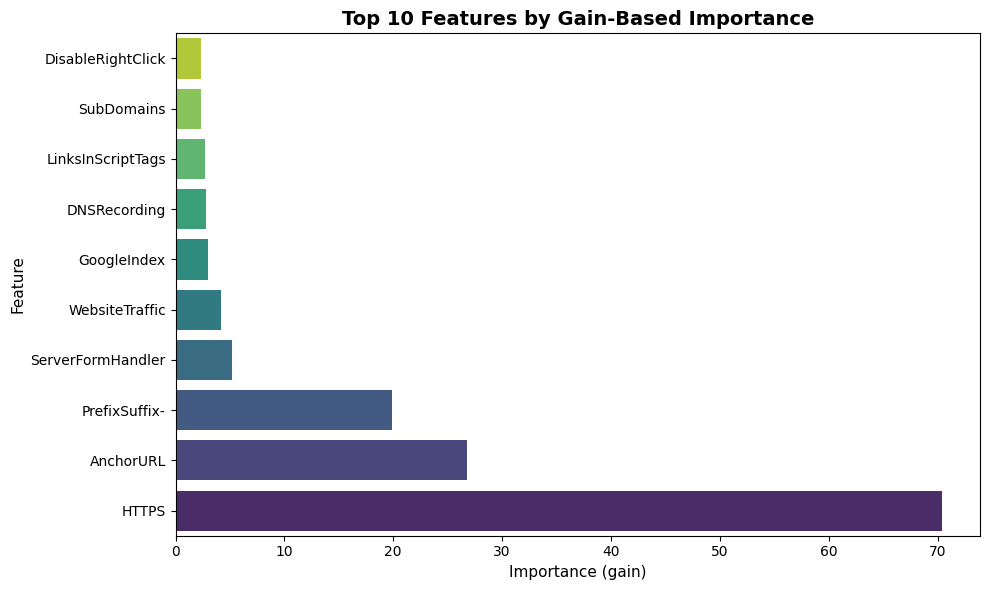

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=importance_df.head(10),
    x='importance_score',
    y='feature_name',
    palette='viridis',
    orient='h',
)
ax.set_title('Top 10 Features by Gain-Based Importance', fontsize=14, weight='bold')
ax.set_xlabel('Importance (gain)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(output_dir / 'feature_importance_top10.png', dpi=300, bbox_inches='tight')
print('Saved plot to:', output_dir / 'feature_importance_top10.png')
plt.show()

SHAP summary ranking (mean |SHAP value|):
       feature_name  shap_mean_abs_value
          AnchorURL             2.810336
              HTTPS             2.550260
     WebsiteTraffic             0.811246
      PrefixSuffix-             0.672176
  LinksInScriptTags             0.626872
  ServerFormHandler             0.568790
         SubDomains             0.524082
LinksPointingToPage             0.501718
            UsingIP             0.499973
       DNSRecording             0.418282
Saved SHAP beeswarm plot to: /output/shap_summary_beeswarm.png


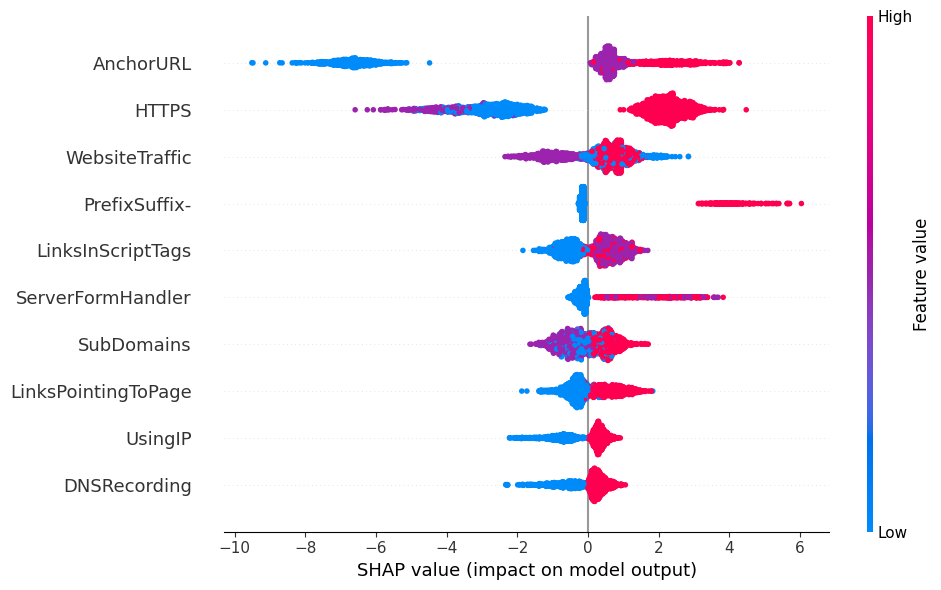


SHAP top-7 vs gain-based top-7 overlap: 5/7 features
Discrepancies noted: ['DNSRecording', 'GoogleIndex', 'LinksInScriptTags', 'SubDomains']
These differences are worth flagging in the write-up as a ranking-consistency check.


In [7]:
import numpy as np
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_array = np.asarray(shap_values[1])
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_array = shap_values[:, :, 1]
else:
    shap_array = np.asarray(shap_values)

if shap_array.ndim != 2:
    raise ValueError(f'Unexpected SHAP value shape: {shap_array.shape}')

shap_importance = pd.Series(
    np.abs(shap_array).mean(axis=0),
    index=X_test.columns,
).sort_values(ascending=False)

shap_rank_df = shap_importance.reset_index()
shap_rank_df.columns = ['feature_name', 'shap_mean_abs_value']
shap_rank_df = shap_rank_df.sort_values('shap_mean_abs_value', ascending=False).reset_index(drop=True)

print('SHAP summary ranking (mean |SHAP value|):')
print(shap_rank_df.head(10).round({'shap_mean_abs_value': 6}).to_string(index=False))

shap.summary_plot(shap_array, X_test, max_display=10, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.tight_layout()
fig.savefig(output_dir / 'shap_summary_beeswarm.png', dpi=300, bbox_inches='tight')
print('Saved SHAP beeswarm plot to:', output_dir / 'shap_summary_beeswarm.png')
plt.show()
plt.close(fig)

# Compare SHAP top-7 to the gain-based top-7 from the previous cell
shap_top7 = shap_rank_df.head(7).set_index('feature_name')['shap_mean_abs_value']
gain_top7 = importance_df.head(7).set_index('feature_name')['importance_score']
shared_features = set(shap_top7.index).intersection(set(gain_top7.index))

print(f'\nSHAP top-7 vs gain-based top-7 overlap: {len(shared_features)}/7 features')
if len(shared_features) == 7:
    print('The SHAP top-7 ranking matches the gain-based top-7 ranking exactly.')
else:
    discrepancies = sorted(set(gain_top7.index).symmetric_difference(set(shap_top7.index)))
    print('Discrepancies noted:', discrepancies)
    print('These differences are worth flagging in the write-up as a ranking-consistency check.')

In [8]:
import json

selected_features = importance_df.head(7)['feature_name'].tolist()
selected_path = output_dir / 'selected_features_top7.txt'
with open(selected_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(selected_features))

json_path = output_dir / 'selected_features_top7.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(selected_features, f, indent=2)

importance_df.to_csv(output_dir / 'feature_importance_ranked.csv', index=False)

print('Saved selected feature subset to:', selected_path)
print('Saved selected feature subset JSON to:', json_path)
print('Saved ranked importance table to:', output_dir / 'feature_importance_ranked.csv')
print('Saved plots already exist in:', output_dir)

Saved selected feature subset to: /output/selected_features_top7.txt
Saved selected feature subset JSON to: /output/selected_features_top7.json
Saved ranked importance table to: /output/feature_importance_ranked.csv
Saved plots already exist in: /output
